In [1]:
import numpy as np
import numpy.linalg as lin
import matplotlib.pylab as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

np.set_printoptions(precision=3, linewidth=150, suppress=True)
plt.style.use(['seaborn-whitegrid','data/cours.mplstyle'])

/tmp/ipykernel_809943/2564280163.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['seaborn-whitegrid','data/cours.mplstyle'])


Dans ce cours on regarde 2 points :
    
* comment améliorer Jacobi
* la convergence des algorithmes itératifs (comment la comprendre et bien l'exploiter)

## Ajouter de l'inertie à Jacobi

La méthode de Jacobi mène au système itératif suivant

$$
{\bf x}^{k+1} = M^{-1} \, ( N\; {\bf x}^k + {\bf b})
$$

On a vu que cette méthode ne converge que si la matrice $B=M^{-1}\, N$ a son rayon spectral inférieur à 1, $\rho(M^{-1}\,N) < 1$.

On peut modifier cette méthode pour qu'elle ait un plus grand rayon de convergence
et donc converge pour plus de matrices. Pour cela on ajoute de l'inertie :

$$
{\bf x}^{k+1} =  w \, M^{-1} \, (N\; {\bf x}^k + {\bf b}) + (1-w) \, {\bf x}^k
$$

avec $0 < w \le 1$.

Si $w = 1$ alors on a Jacobi classique et si $w = 0$ alors on ne bouge pas, ${\bf x}^{k+1} = {\bf x}^k$.

On parle d'inertie car on voit qu'on avance moins vite puisque la nouvelle valeur de ${\bf x}^{k+1}$
est comprise entre l'ancienne  valeur de ${\bf x}^{k+1}$ et ${\bf x}^k$.

L'idée est qu'avec l'intertie on va peut-être entrer dans la zone de convergence alors que sans on aurait sauté par dessus.

Cette méthode s'appelle la **surrelaxation** (*over-relaxation* en anglais).

### Programmons l'inertie pour Jacobi

On commence par un Jacobi simple pour vérifier qu'on diverge.

In [3]:
np.random.seed(799)

A = np.random.randint(10, size=(4,4))
b = A.sum(axis=1)                     # ainsi la solution est [1,1,1,1]
print('A:\n', A, "\nb:\n", b, "\n")

M = np.diag(A)        # attention, c'est un vecteur
N = np.diag(M) - A
print(f"M:\n {np.diag(M)}\nN:\n {N}\n")

x0 = np.random.random(4)
x = x0
for i in range(20):
    print(f"x_{i} = {x}")
    x = (N @ x + b) / M

A:
 [[5 7 6 0]
 [1 7 2 5]
 [5 6 5 1]
 [0 6 3 7]] 
b:
 [18 15 17 16] 

M:
 [[5 0 0 0]
 [0 7 0 0]
 [0 0 5 0]
 [0 0 0 7]]
N:
 [[ 0 -7 -6  0]
 [-1  0 -2 -5]
 [-5 -6  0 -1]
 [ 0 -6 -3  0]]

x_0 = [0.062 0.652 0.185 0.852]
x_1 = [2.465 1.472 2.384 1.647]
x_2 = [-1.322 -0.067 -1.161  0.002]
x_3 = [5.088 2.662 4.803 2.841]
x_4 = [-5.89  -1.986 -5.451 -2.055]
x_5 = [12.921  6.009 12.084  6.324]
x_6 = [-19.314  -7.672 -17.997  -8.044]
x_7 = [35.937 15.79  33.53  16.575]
x_8 = [-58.741 -24.41  -54.8   -25.618]
x_9 = [103.534  44.49   96.557  46.694]
x_10 = [-174.554  -73.588 -162.861  -77.23 ]
x_11 = [302.056 128.775 281.706 135.159]
x_12 = [-514.732 -218.038 -480.218 -228.824]
x_13 = [885.114 376.327 825.542 394.983]
x_14 = [-1513.908  -642.302 -1412.303  -674.084]
x_15 = [2597.587 1103.419 2422.887 1158.103]
x_16 = [-4448.651 -1888.411 -4149.91  -1981.882]
x_17 = [7627.267 3238.983 7114.521 3399.456]
x_18 = [-13068.402  -5548.37  -12190.539  -5823.066]
x_19 = [22399.965  9511.401 20894.459  998

Ajoutons maintenant l'inertie à Jacobi :

In [19]:
x = x0    # on reprend la même valeur initiale sinon la comparaison serait faussée
w = 1   # on choisit w 
for i in range(30):
    print(f"x_{i} = {x}")
    x = w * (N @ x + b) / M + (1-w) * x

x_0 = [0.062 0.652 0.185 0.852]
x_1 = [2.465 1.472 2.384 1.647]
x_2 = [-1.322 -0.067 -1.161  0.002]
x_3 = [5.088 2.662 4.803 2.841]
x_4 = [-5.89  -1.986 -5.451 -2.055]
x_5 = [12.921  6.009 12.084  6.324]
x_6 = [-19.314  -7.672 -17.997  -8.044]
x_7 = [35.937 15.79  33.53  16.575]
x_8 = [-58.741 -24.41  -54.8   -25.618]
x_9 = [103.534  44.49   96.557  46.694]
x_10 = [-174.554  -73.588 -162.861  -77.23 ]
x_11 = [302.056 128.775 281.706 135.159]
x_12 = [-514.732 -218.038 -480.218 -228.824]
x_13 = [885.114 376.327 825.542 394.983]
x_14 = [-1513.908  -642.302 -1412.303  -674.084]
x_15 = [2597.587 1103.419 2422.887 1158.103]
x_16 = [-4448.651 -1888.411 -4149.91  -1981.882]
x_17 = [7627.267 3238.983 7114.521 3399.456]
x_18 = [-13068.402  -5548.37  -12190.539  -5823.066]
x_19 = [22399.965  9511.401 20894.459  9982.548]
x_20 = [-38385.712 -16298.089 -35806.756 -17105.112]
x_21 = [65789.032 27934.255 61367.842 29317.829]
x_22 = [-112745.767  -47871.266 -105170.303  -50241.865]
x_23 = [193227.736 

La solution recherchée étant [1,1,1,1] ca semble bien marcher !


### Étudions la convergence

Pour bien comprendre une méthode itérative il faut étudier sa convergence et donc tracer une courbe
de l'erreur absolue (lorsqu'on connait la solution), ou de l'erreur relative (entre deux ${\bf x}^i$ successifs)
ou du résidu ($||A \, {\bf x}^i - {\bf b}||$) ou de toute autre mesure qui a du sens.

Regardons :

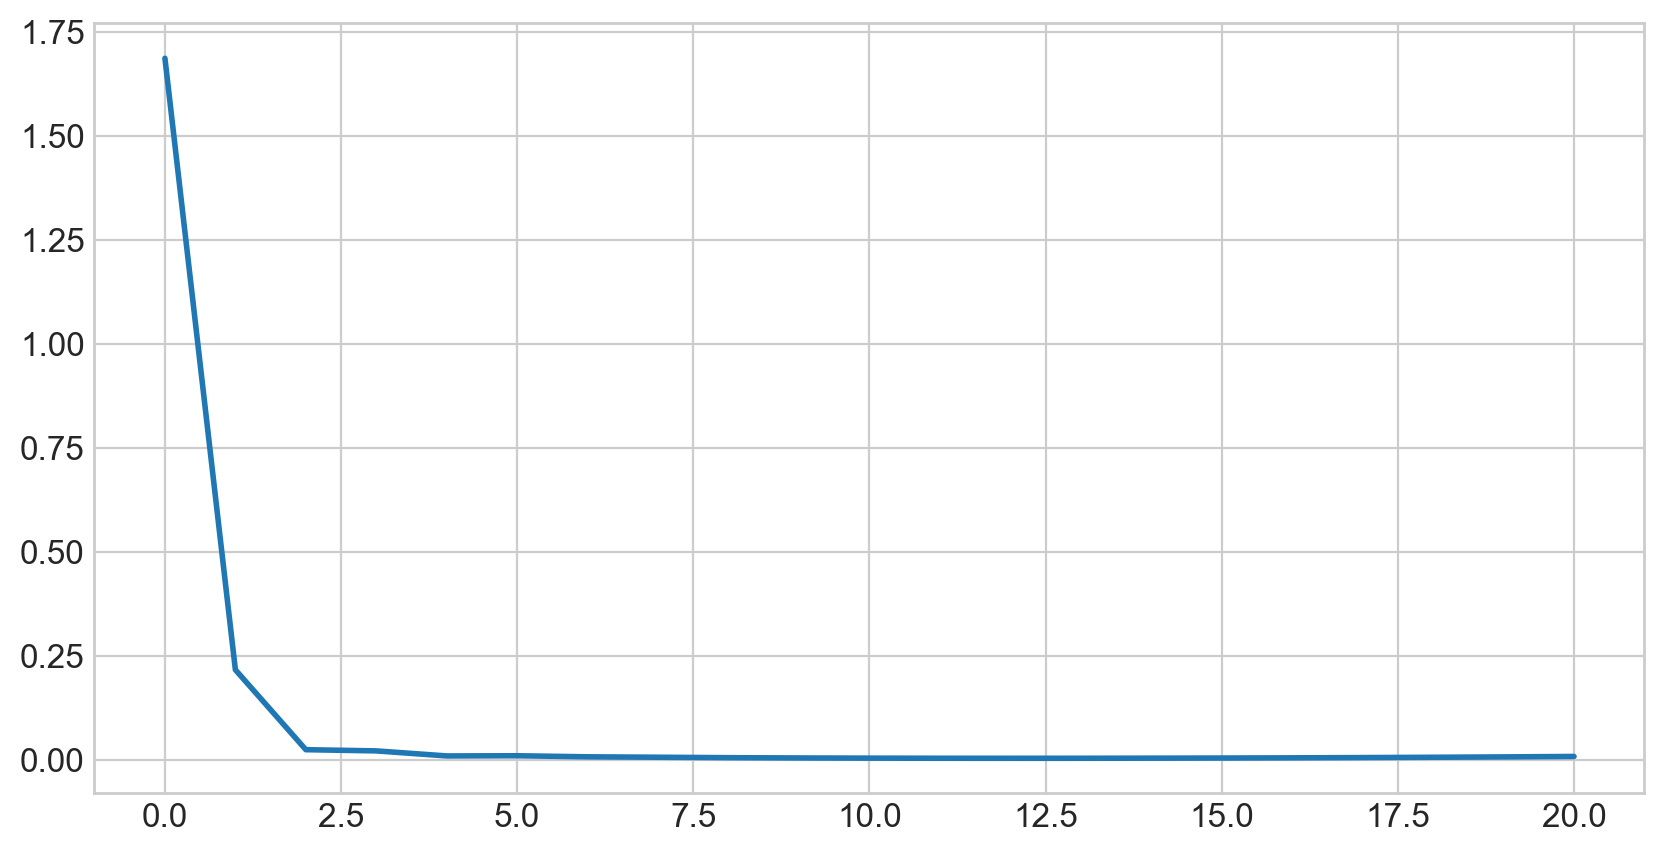

In [21]:
x = x0    # on reprend la même valeur initiale sinon la comparaison serait faussée
w = 0.5   # on choisit w 
error = [np.square(x - np.ones(4)).sum()]
for i in range(20):
    x = w * (N @ x + b) / M + (1-w) * x
    error.append(np.square(x - np.ones(4)).sum())
plt.plot(range(len(error)), error);

A priori cela semble bien, sauf qu'en fait on ne voit rien car l'échelle empêche de voir ce qui se passe à
la fin.

Regardons en échelle logarithmique :

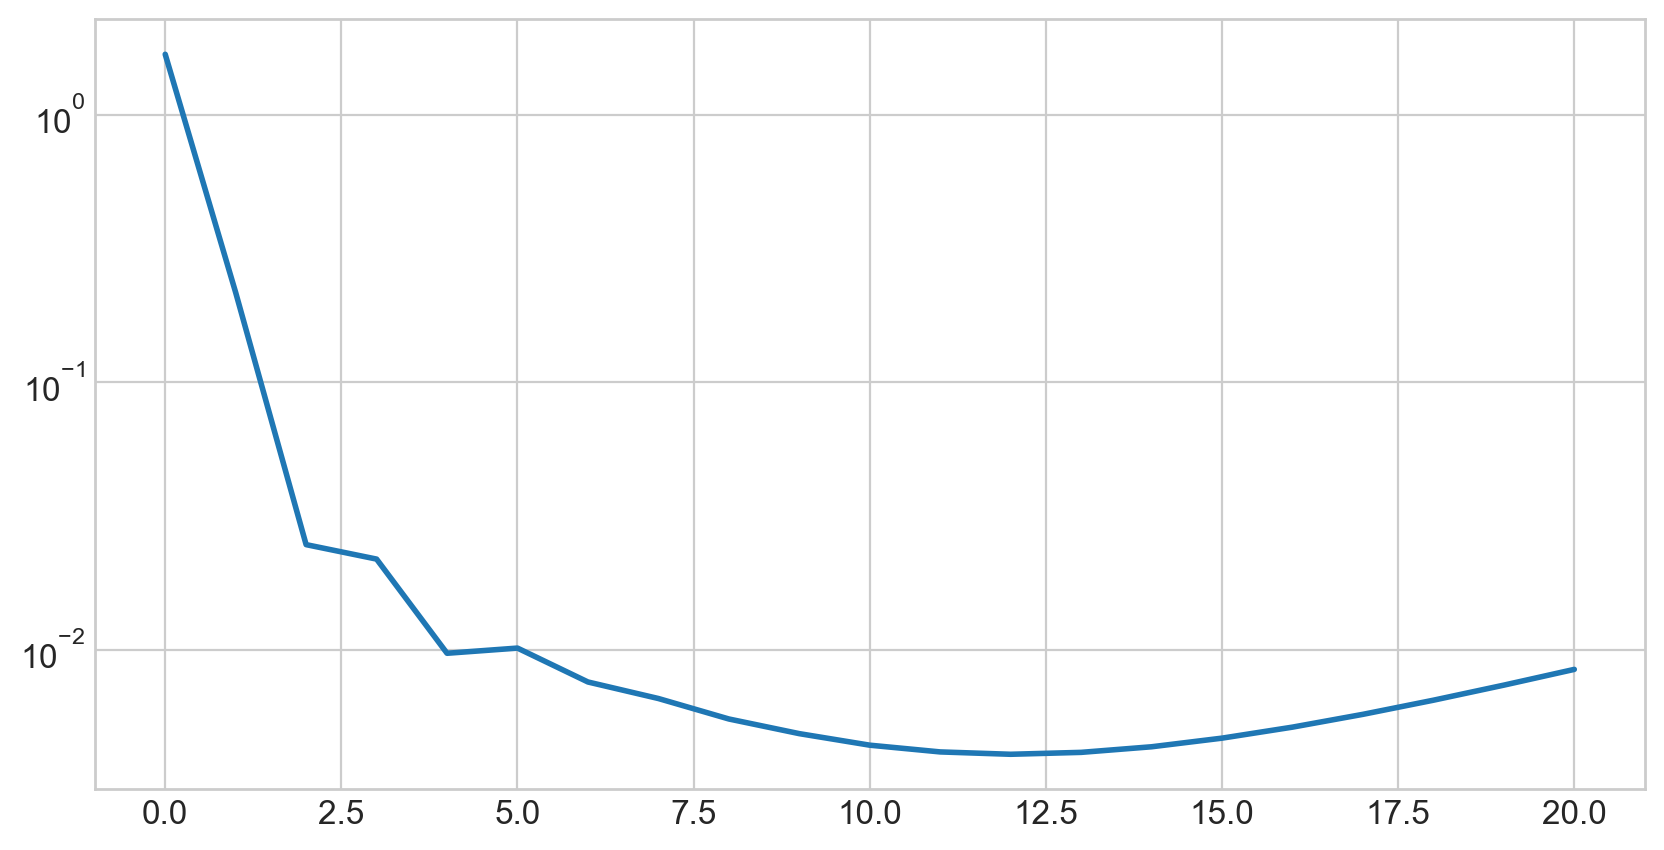

In [22]:
plt.plot(range(len(error)), error)
plt.semilogy();

Oula, la fin fait peur...

Moralité : **Il faut toujours regarder une erreur en échelle logarithmique.** 

Puiqu'on mesure quelque chose 
qui doit tendre vers 0, avec une echelle normale on est vite écrasé et donc on ne voit pas si on est à 
$10^{-3}$ ou $10^{-6}$ alors que c'est très très différent.

De même si on diverge on ne verra pas le début car un échelle linéraire s'ajustera sur les dernières valeurs qui 
peuvent être très grandes.

Reprenons notre calcul sur plus d'itérations.

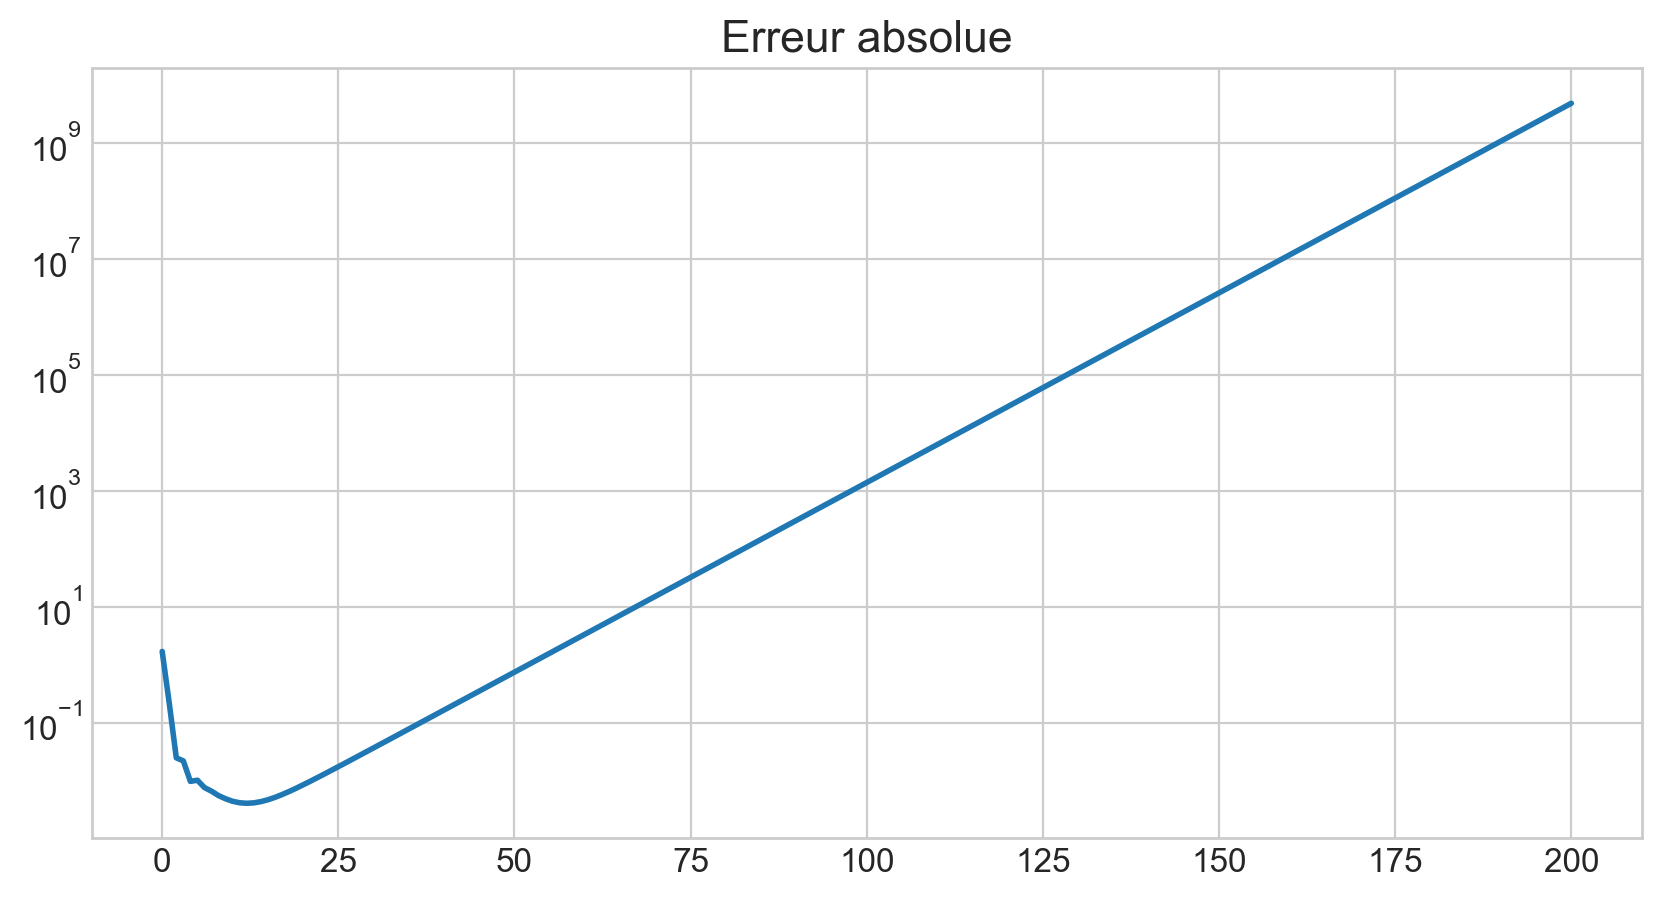

In [23]:
x = x0    # on reprend la même valeur initiale sinon la comparaison serait faussée
w = 0.5   # on choisit w 
error = [np.square(x - np.ones(4)).sum()]
for i in range(200):
    x = w * (N @ x + b) / M + (1-w) * x
    error.append(np.square(x - np.ones(4)).sum())
plt.plot(range(len(error)), error)
plt.title('Erreur absolue')
plt.semilogy();

Donc on s'est approché de la solution puis on a divergé ce qui est mieux que de diverger directement.

#### Erreur relative 

Aurait-on pu le voir si on n'avait pas connu la solution ? Regardons l'écart entre deux ${\bf x}^k$ successifs.

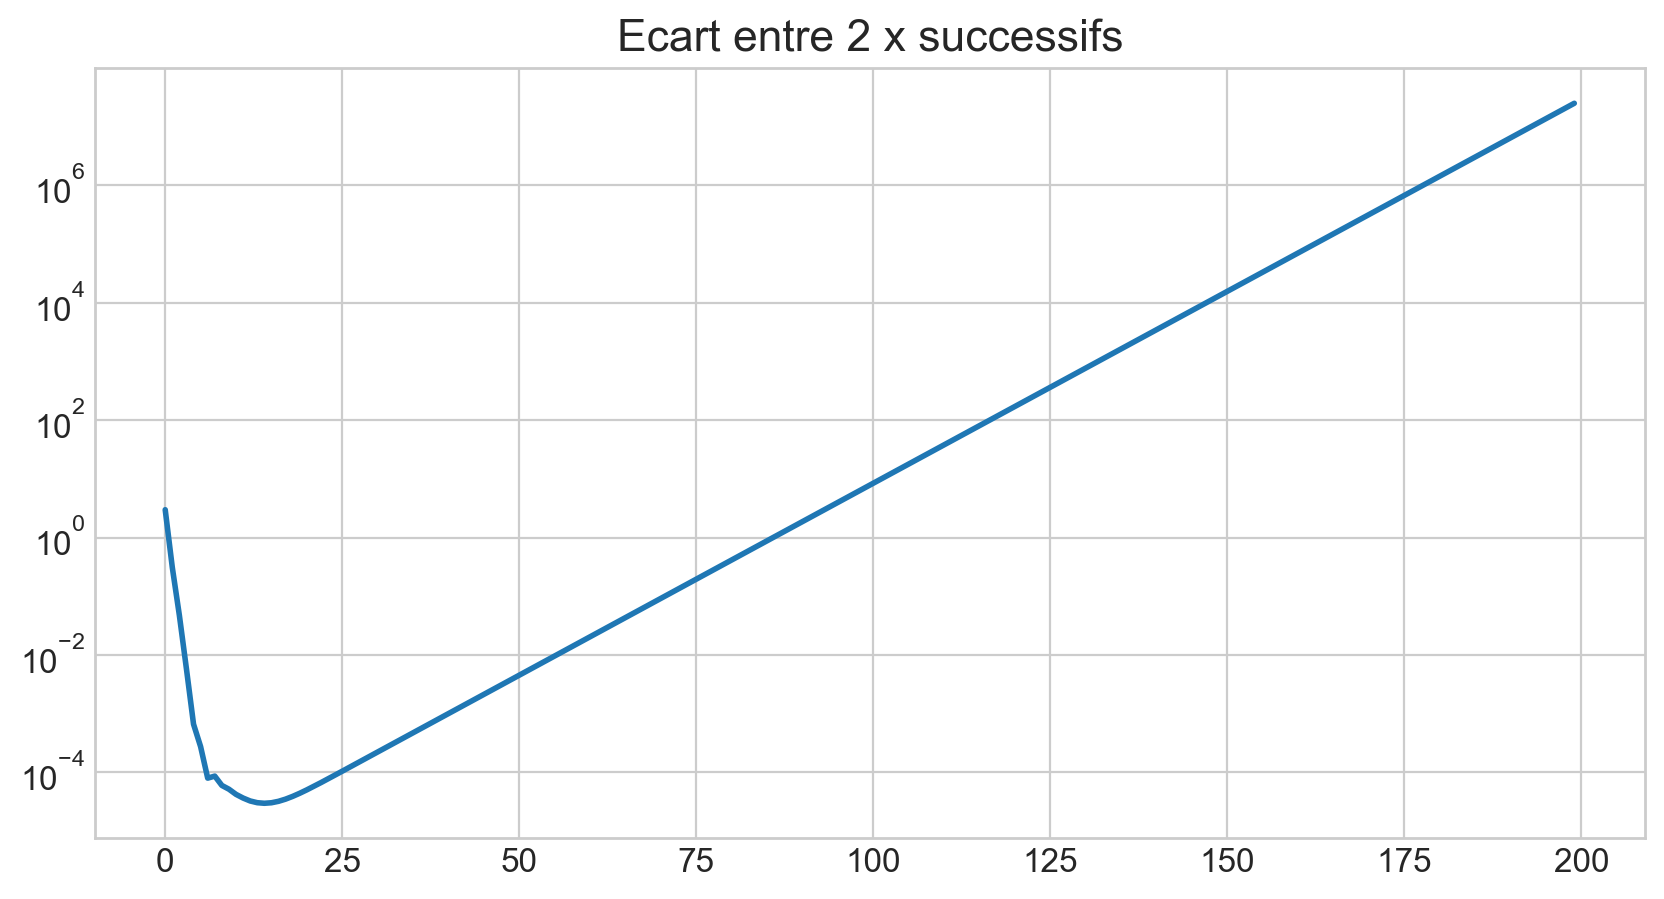

In [24]:
x = x0    # on reprend la même valeur initiale sinon la comparaison serait faussée
w = 0.5   # on choisit w 
error2 = []
for i in range(200):
    old_x = x
    x = w * (N @ x + b) / M + (1-w) * x
    error2.append(np.square(x - old_x).sum())
plt.plot(range(len(error2)), error2)
plt.title('Ecart entre 2 x successifs')
plt.semilogy();

Il semble bien qu'il y ait une relation forte entre l'écart entre deux **x** successif et l'erreur absolue.
Vérifions :

In [25]:
k_min = np.argmin(error)
k2_min = np.argmin(error2)
print('Itération présentant le minimum : ', k_min, k2_min)
print('Erreur absolue minimum                                        : ', min(error))
print("Erreur absolue minimum devinée à partir du minimum de l'écart : ", error[k2_min])

Itération présentant le minimum :  12 14
Erreur absolue minimum                                        :  0.0040626765429533146
Erreur absolue minimum devinée à partir du minimum de l'écart :  0.004333899458826035


L'écart entre deux **x** successifs est une facon simple et relativement efficace de savoir quand arrêter un algorithme
itératif.

#### Résidu

Enfin on peut calculer le résidu à savoir $||A \, {\bf x} - {\bf b}||$ mais c'est $n^2$ opérations :

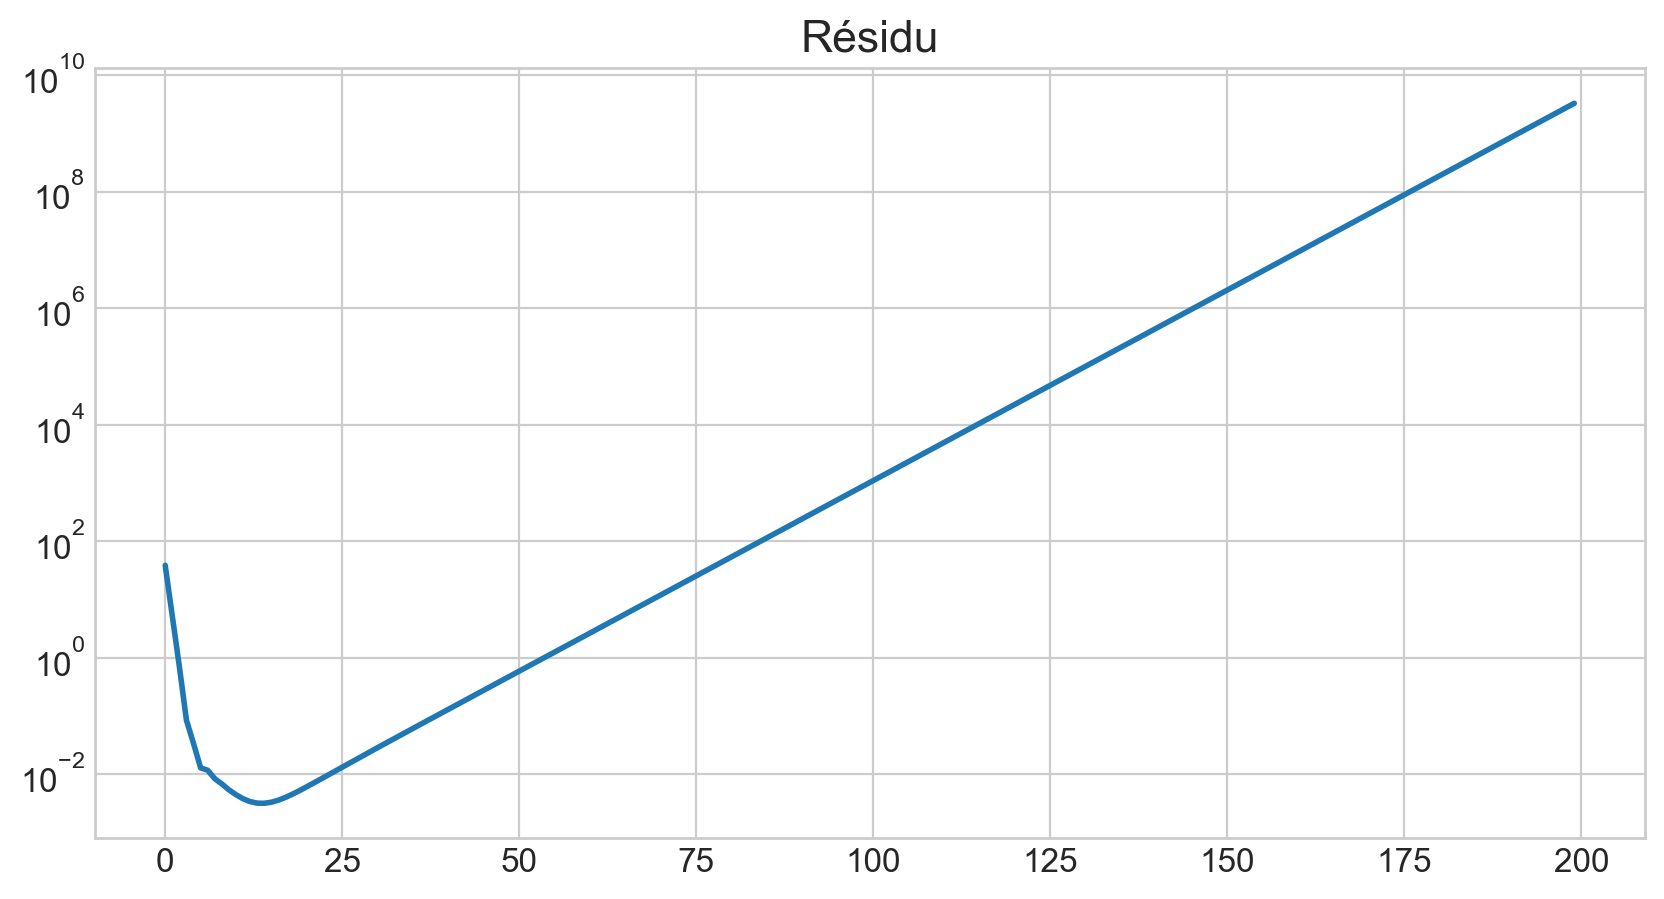

In [26]:
x = x0    # on reprend la même valeur initiale sinon la comparaison serait faussée
w = 0.5   # on choisit w 
residu = []
for i in range(200):
    old_x = x
    x = w * (N @ x + b) / M + (1-w) * x
    residu.append(np.square(A @ x - b).sum())
plt.plot(range(len(residu)), residu)
plt.title('Résidu')
plt.semilogy();

### Testons d'autres matrices avec cet algorithme



In [35]:
def mk_A(seed):
    np.random.seed(seed)
    return np.random.randint(10, size=(4,4))

A = mk_A(234)
b = A.sum(axis=1)                    

M = np.diag(A)    
N = np.diag(M) - A 

x0 = np.random.random(4)

In [36]:
def plot_error(M, N, b, x0, w, n=200):
    x = x0 
    error = [np.square(x - np.ones(4)).sum()]
    error2 = []
    for i in range(n):
        old_x = x
        x = w * (N @ x + b) / M + (1-w) * x
        error.append(np.square(x - np.ones(4)).sum())
        error2.append(np.square(x - old_x).sum())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    ax1.plot(range(len(error)), error)
    ax1.set_title('Erreur absolue')
    ax1.semilogy();
    ax2.plot(range(len(error2)), error2)
    ax2.set_title('Erreur relative')
    ax2.semilogy()
    print("Itération du minimum :",np.argmin(error), np.argmin(error2))

Itération du minimum : 17 40


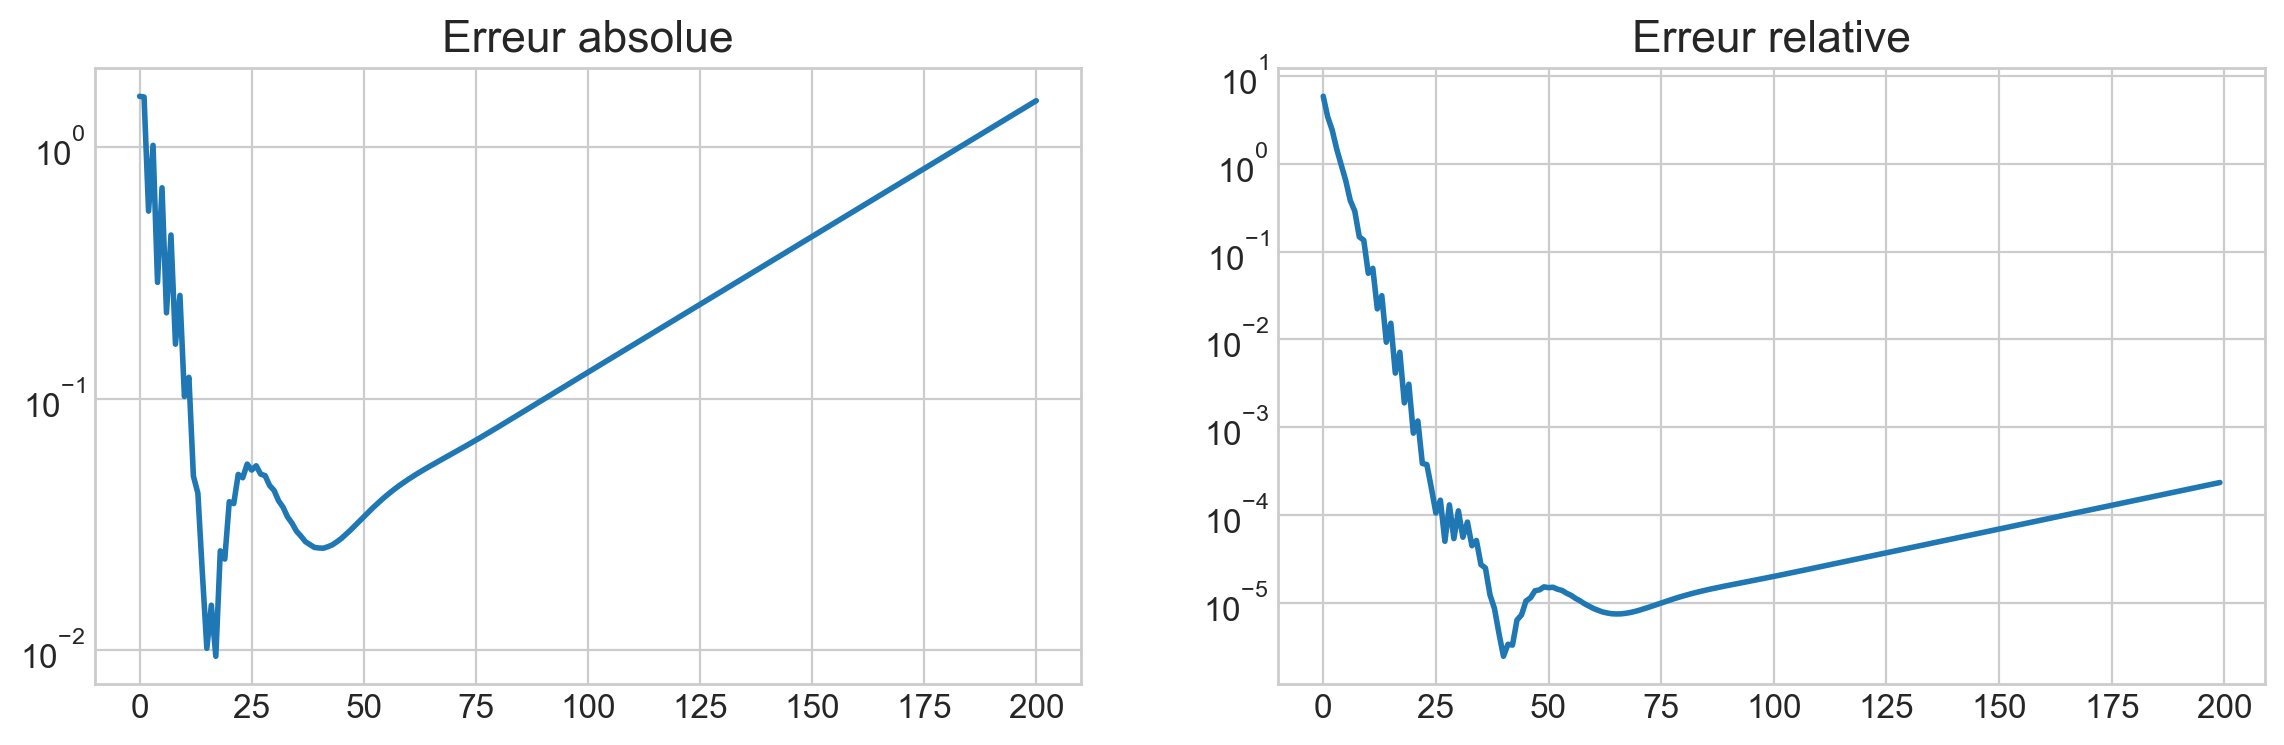

In [38]:
plot_error(M, N, b, x0, w=0.5);

On retrouve le même comportement (convergence puis divergence) mais en nettement plus chaotique.

On peut réduire les oscillation en augmentant l'inertie c. à d. en diminuant $w$ :

Itération du minimum : 81 209


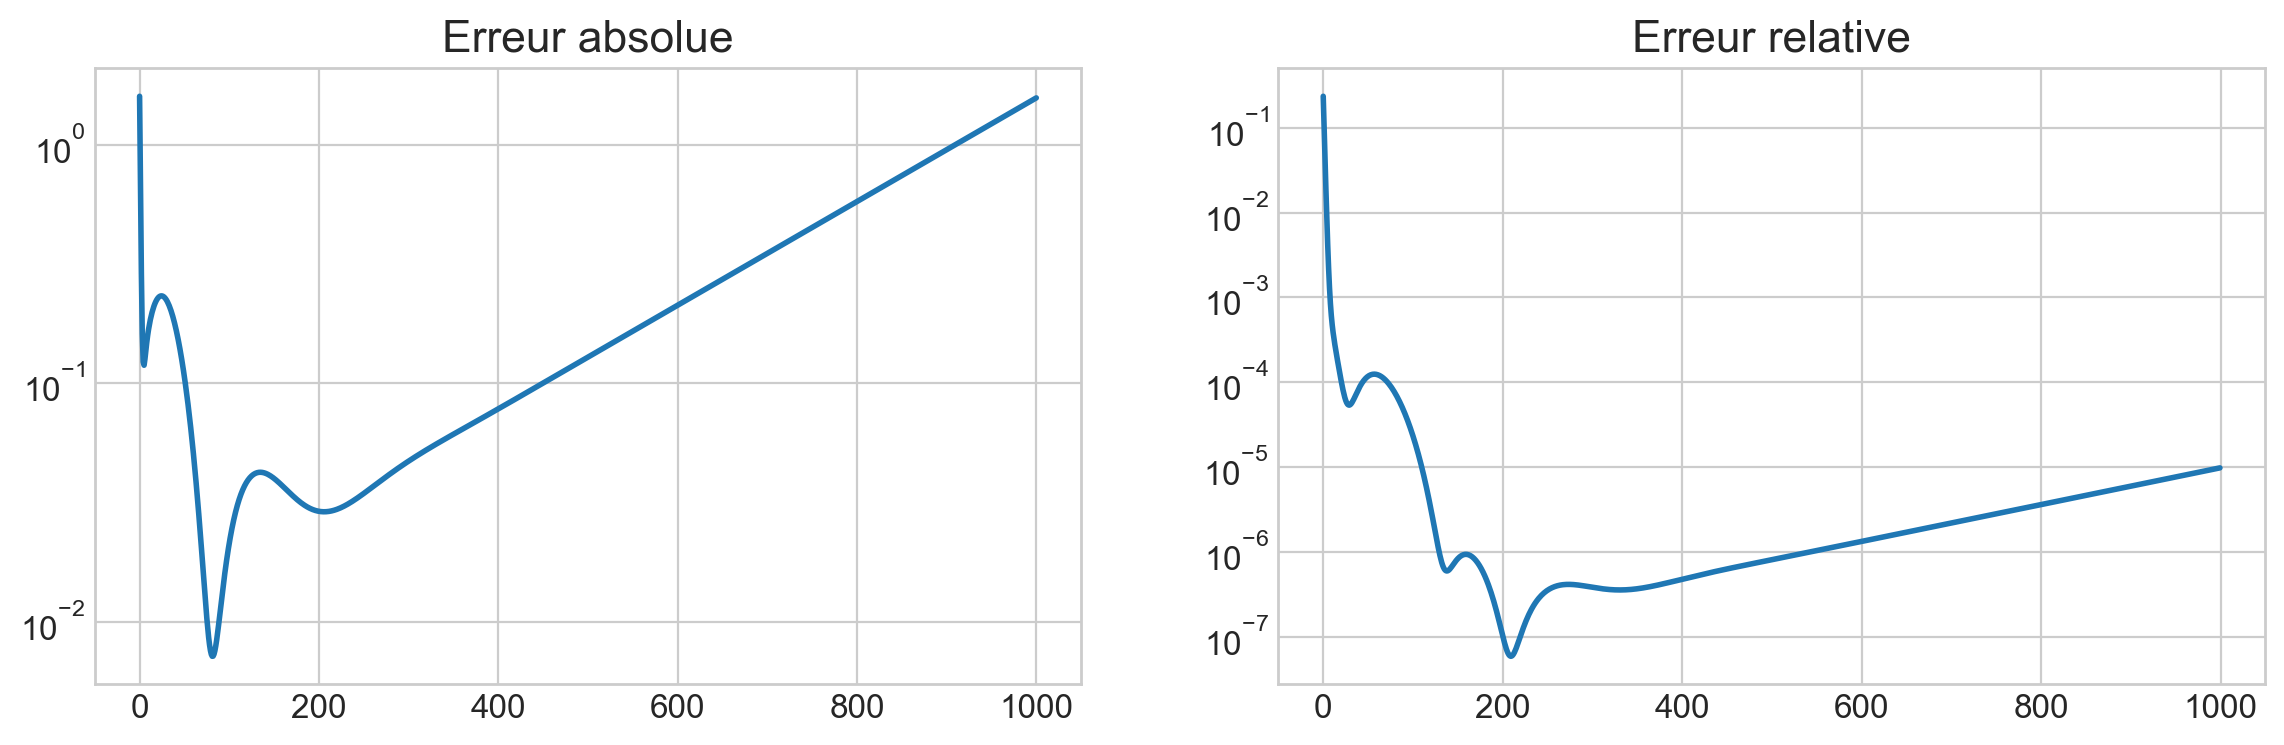

In [39]:
error2 = plot_error(M, N, b, x0, w=0.1, n=1000) 
# w 5 fois plus petit donc je fais 5 fois plus d'itération pour "avancer" d'autant (grosso modo)

Les oscillations ont disparu ! Mais on a payé le prix fort puisqu'on a du faire 5 fois plus d'itérations.

On constate que dans les 2 cas l'erreur relative (entre deux $x$ successifs) ne donne pas le bon minumum.
Donc arrêter un algorithme itératif en fonction de l'erreur relative n'est pas toujours le plus efficace.

Regardons ce que donne le résidu :

Itération du minimum : 218


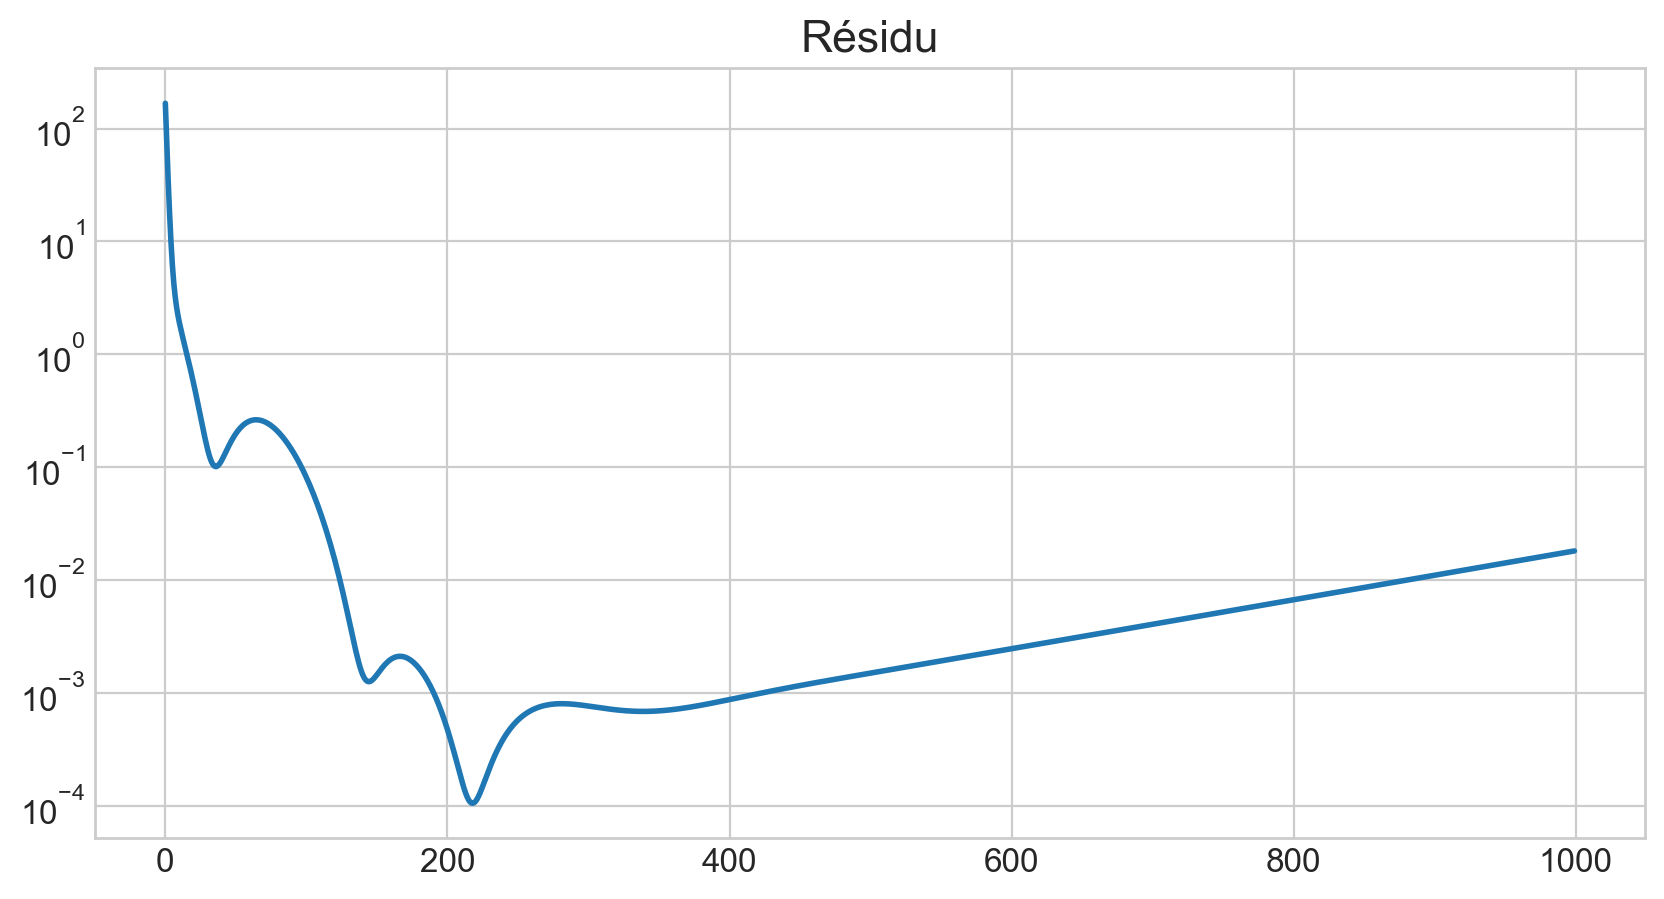

In [40]:
x = x0 
w = 0.1
residu = []
for i in range(1000):
    x = w * (N @ x + b) / M + (1-w) * x
    residu.append(np.square(A @ x - b).sum())
plt.plot(range(len(residu)), residu)
plt.title('Résidu')
plt.semilogy();
print("Itération du minimum :", np.argmin(residu))

#### Nouvelle matrice

[[2 2 6 1]
 [3 9 6 1]
 [0 1 9 0]
 [0 9 3 4]]
Itération du minimum : 154 154


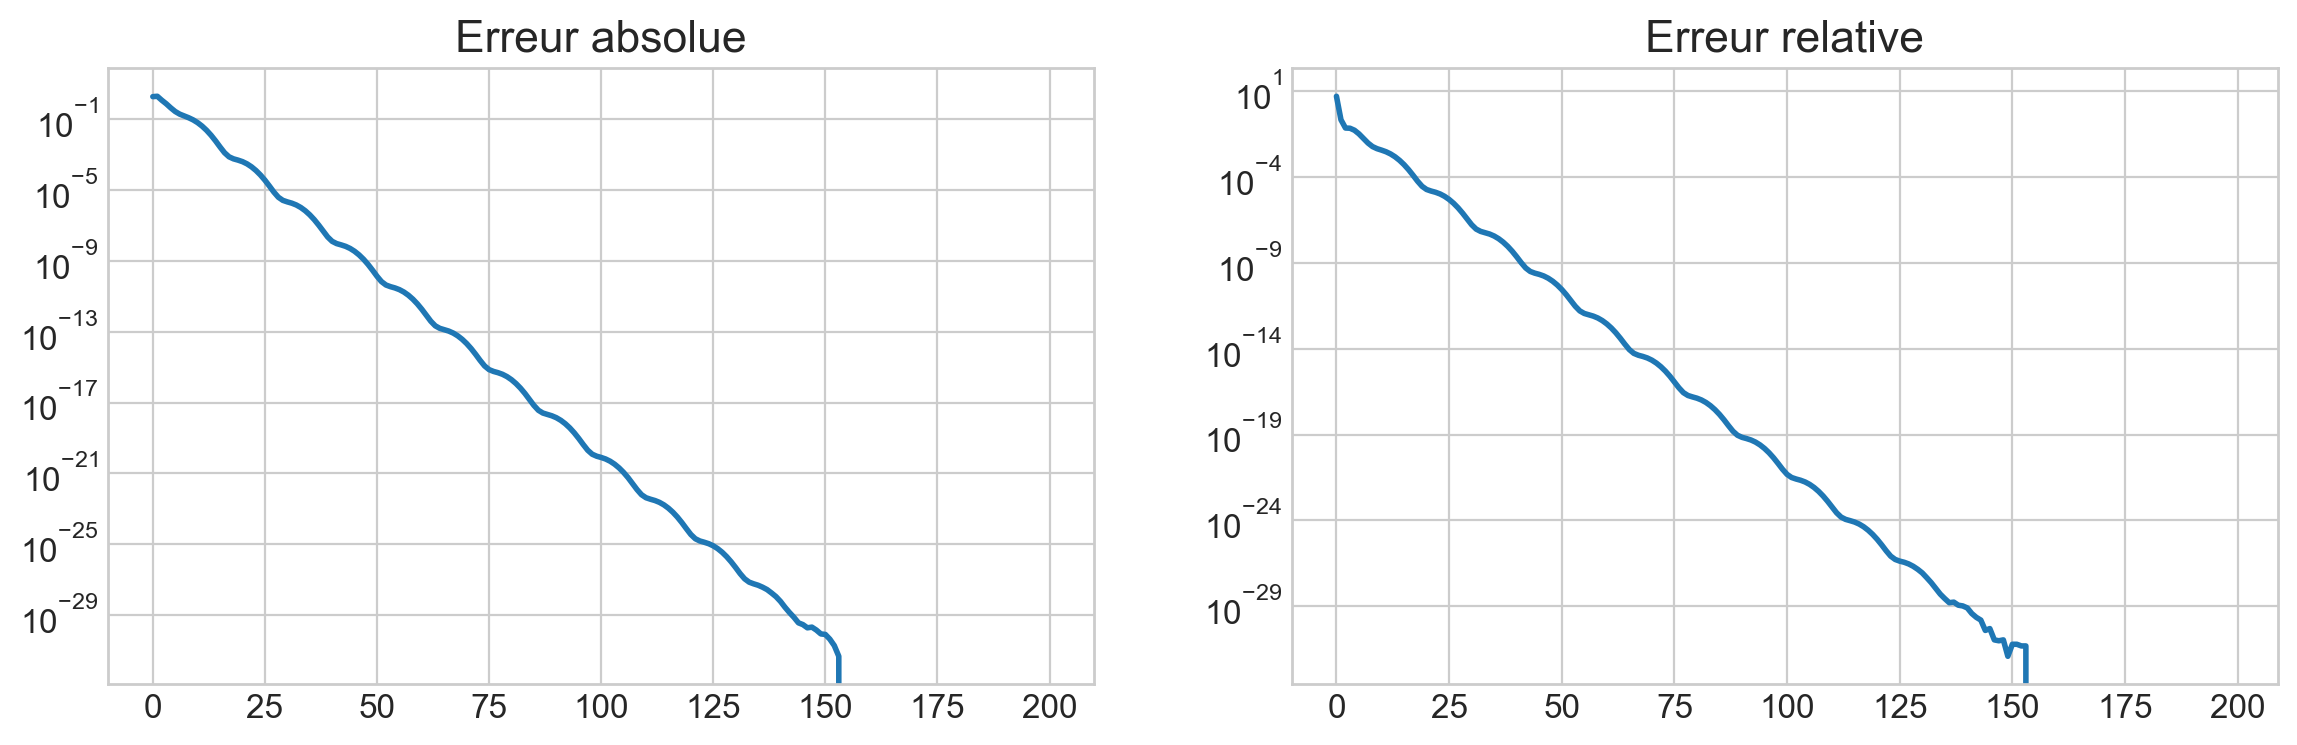

In [48]:
A = mk_A(123)
b = A.sum(axis=1)                    

M = np.diag(A)    
N = np.diag(M) - A 

x0 = np.random.random(4)
print(A)
plot_error(M, N, b, x0, w=0.5)

Voici un cas avec une convergence parfaite. Notons qu'on s'est arrêté à l'itération 150 lorsqu'on est passé
en dessous de la précision de la machine (les valeurs suivantes devant être 0 et comme log(0) = $-\infty$,
matplolib ne les affiche pas).

Vérifions quand même que la méthode de Jacobi de base n'aurait 
pas marché :

In [42]:
x = x0
for i in range(20):
    print(f"x_{i} = {x}")
    x = (N @ x + b) / M

x_0 = [0.398 0.738 0.182 0.175]
x_1 = [4.127 1.837 1.029 2.203]
x_2 = [-0.526 -0.195  0.907 -0.906]
x_3 = [3.427 1.782 1.133 3.759]
x_4 = [-1.56  -0.204  0.913 -0.86 ]
x_5 = [3.395 2.118 1.134 3.775]
x_6 = [-1.907 -0.196  0.876 -1.616]
x_7 = [3.877 2.342 1.133 3.784]
x_8 = [-2.133 -0.357  0.851 -2.12 ]
x_9 = [4.364 2.49  1.151 4.165]
x_10 = [-2.525 -0.574  0.834 -2.467]
x_11 = [4.804 2.671 1.175 4.665]
x_12 = [-3.027 -0.792  0.814 -2.89 ]
x_13 = [5.293 2.898 1.199 5.17 ]
x_14 = [-3.581 -1.027  0.789 -3.421]
x_15 = [5.87  3.159 1.225 5.719]
x_16 = [-4.194 -1.298  0.76  -4.026]
x_17 = [6.531 3.45  1.255 6.35 ]
x_18 = [-4.891 -1.608  0.728 -4.704]
x_19 = [7.277 3.779 1.29  7.073]


Jacobi de base diverge, donc c'est bien l'inertie qui a permis de converger.

#### Nouvelle matrice

Itération du minimum : 0 0


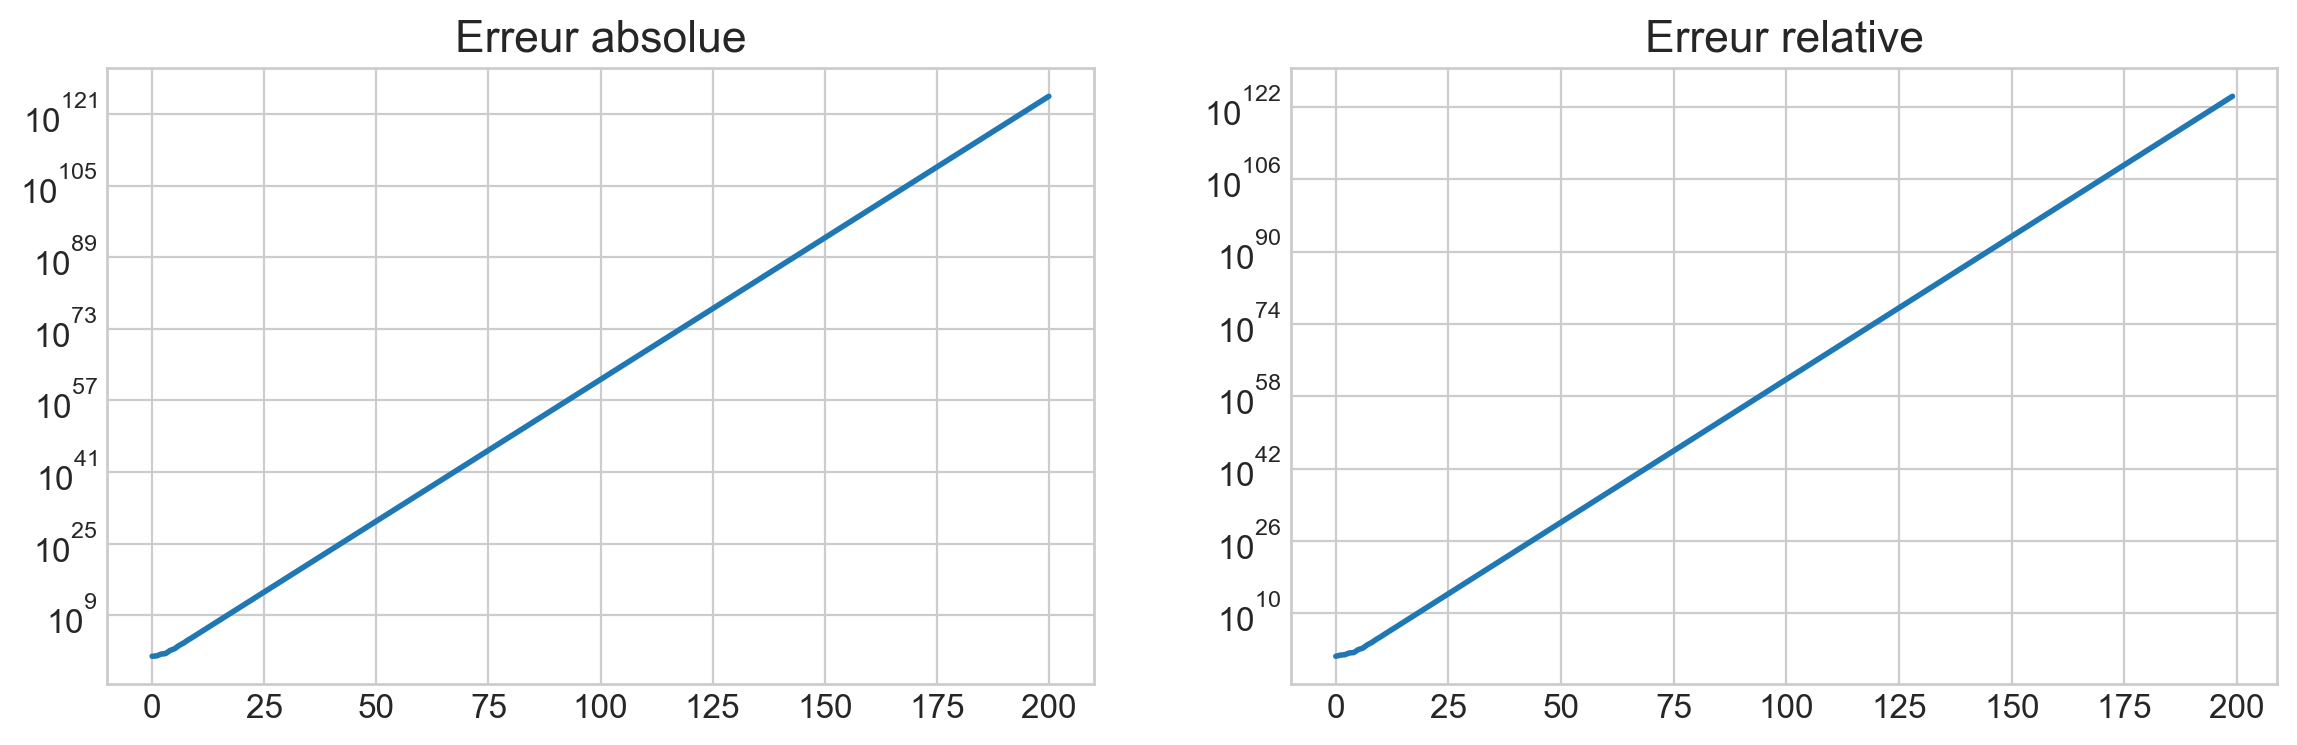

In [52]:
A = mk_A(16)
b = A.sum(axis=1)                    

M = np.diag(A)    
N = np.diag(M) - A 

x0 = np.random.random(4)

plot_error(M, N, b, x0, w=0.5)

Divergence directe mais si on baisse $w$ on constate qu'on est dans le 1er cas :

Itération du minimum : 32 38


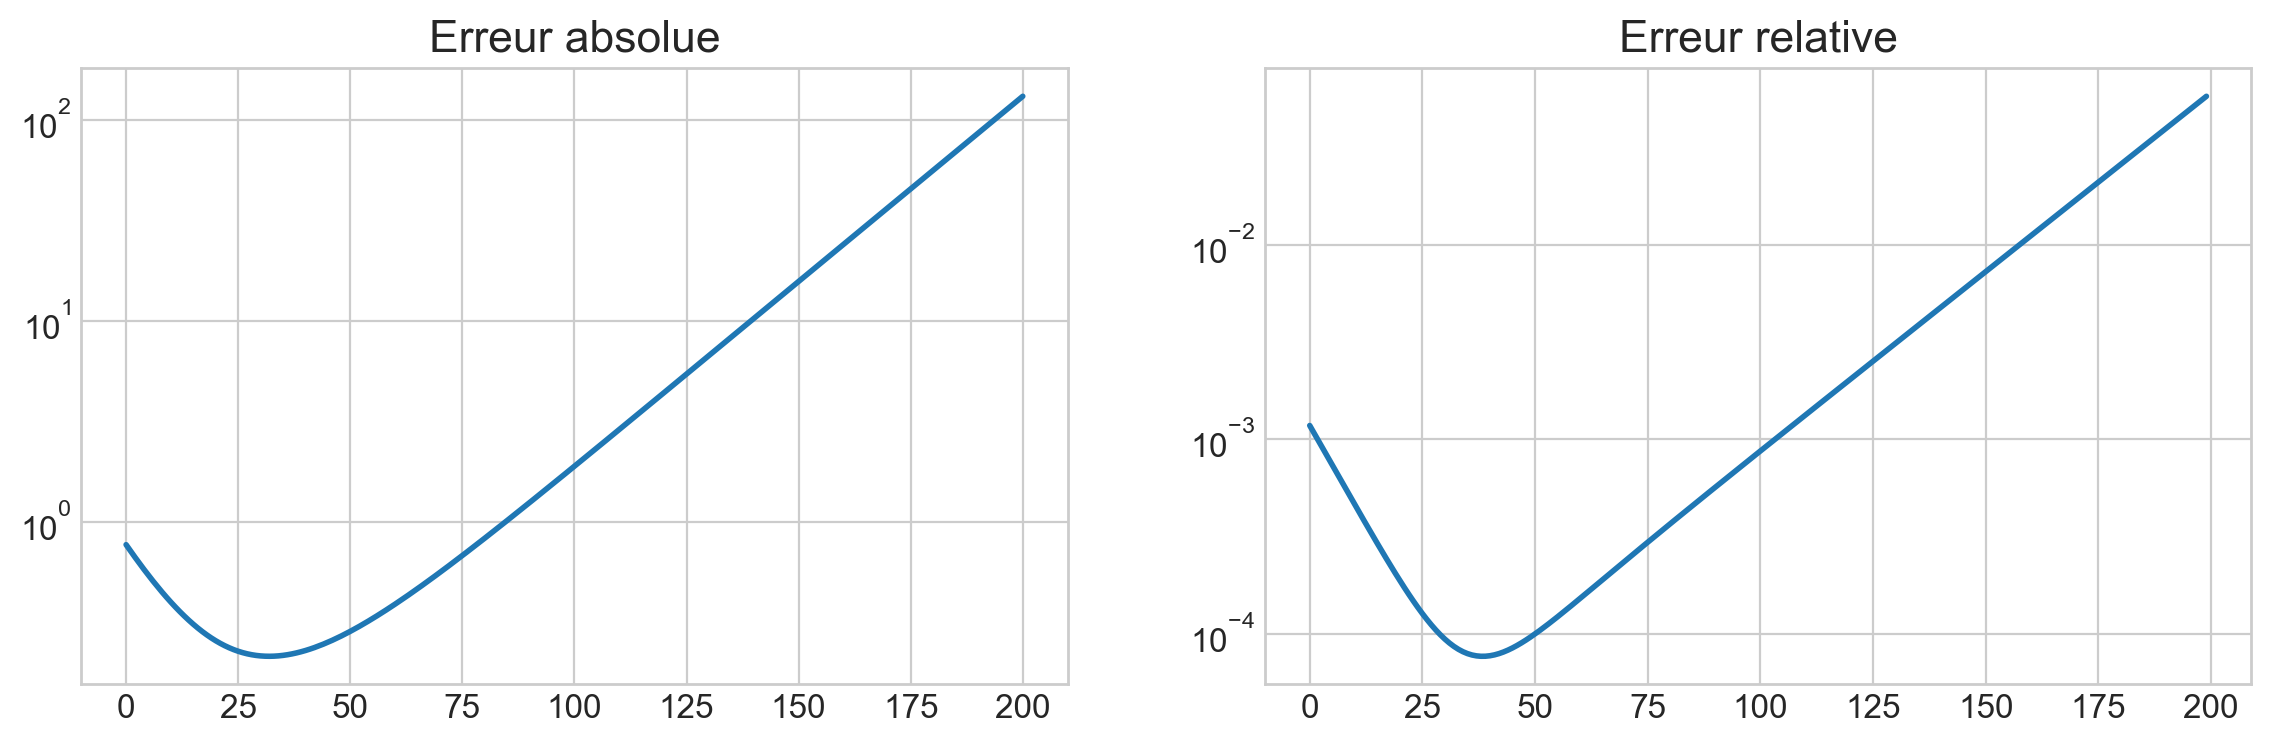

In [16]:
plot_error(M, N, b, x0, w=0.01)

Mais ça reste pas terrible. Au mieux on n'est même pas à $10^{-1}$.

## Normaliser

Cette dernière remarque n'a de sens que si on sait à quoi on se compare. 

* Si la solution cherchée est un milliard, avoir une erreur de 0.1 est très bien.
* Si la solution cherchée est 0.01, une erreur de 0.1 est énorme.

On ne peut donc juger une erreur qu'en fonction d'une référence. Si on connais la solution exacte, alors 
elle est la bonne référence.

$$
\frac{||{\bf x}^k - {\bf x}||}{||{\bf x}||}
$$

De même l'erreur entre 2 itérations successives n'a de sens que normalisée.
Si $||{\bf x}^k|| = 1 000 000$ alors $||{\bf x}^k - {\bf x}^{k-1}|| = 1$ est bien mais ce n'est pas le cas
si $||{\bf x}^k|| = 1$.

Aussi on compare la différence entre 2 itérations avec le **x** courant ou le précédant :

$$
\frac{||{\bf x}^{k+1} - {\bf x}^k||}{||{\bf x}^k||}
$$

Faisons le et regardons nos résultats précédents.

In [60]:
def plot_error_normalized(M, N, b, x0, w, n=200):
    x = x0 
    error = [np.square(x - np.ones(4)).sum()]
    error2 = []
    for i in range(n):
        old_x = x
        x = w * (N @ x + b) / M + (1-w) * x
        error.append((np.square(x - np.ones(4)).sum())/4)               # normalisé par rapport à la solution
        error2.append((np.square(x - old_x).sum())/np.square(x).sum())  # normalisé par rapport à x
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    ax1.plot(range(len(error)), error)
    ax1.set_title('Erreur absolue normalisée')
    ax1.semilogy();
    ax2.plot(range(len(error2)), error2)
    ax2.set_title('Erreur relative normalisée')
    ax2.semilogy()
    print("Itération du minimum :",np.argmin(error), np.argmin(error2))

Itération du minimum : 60 70


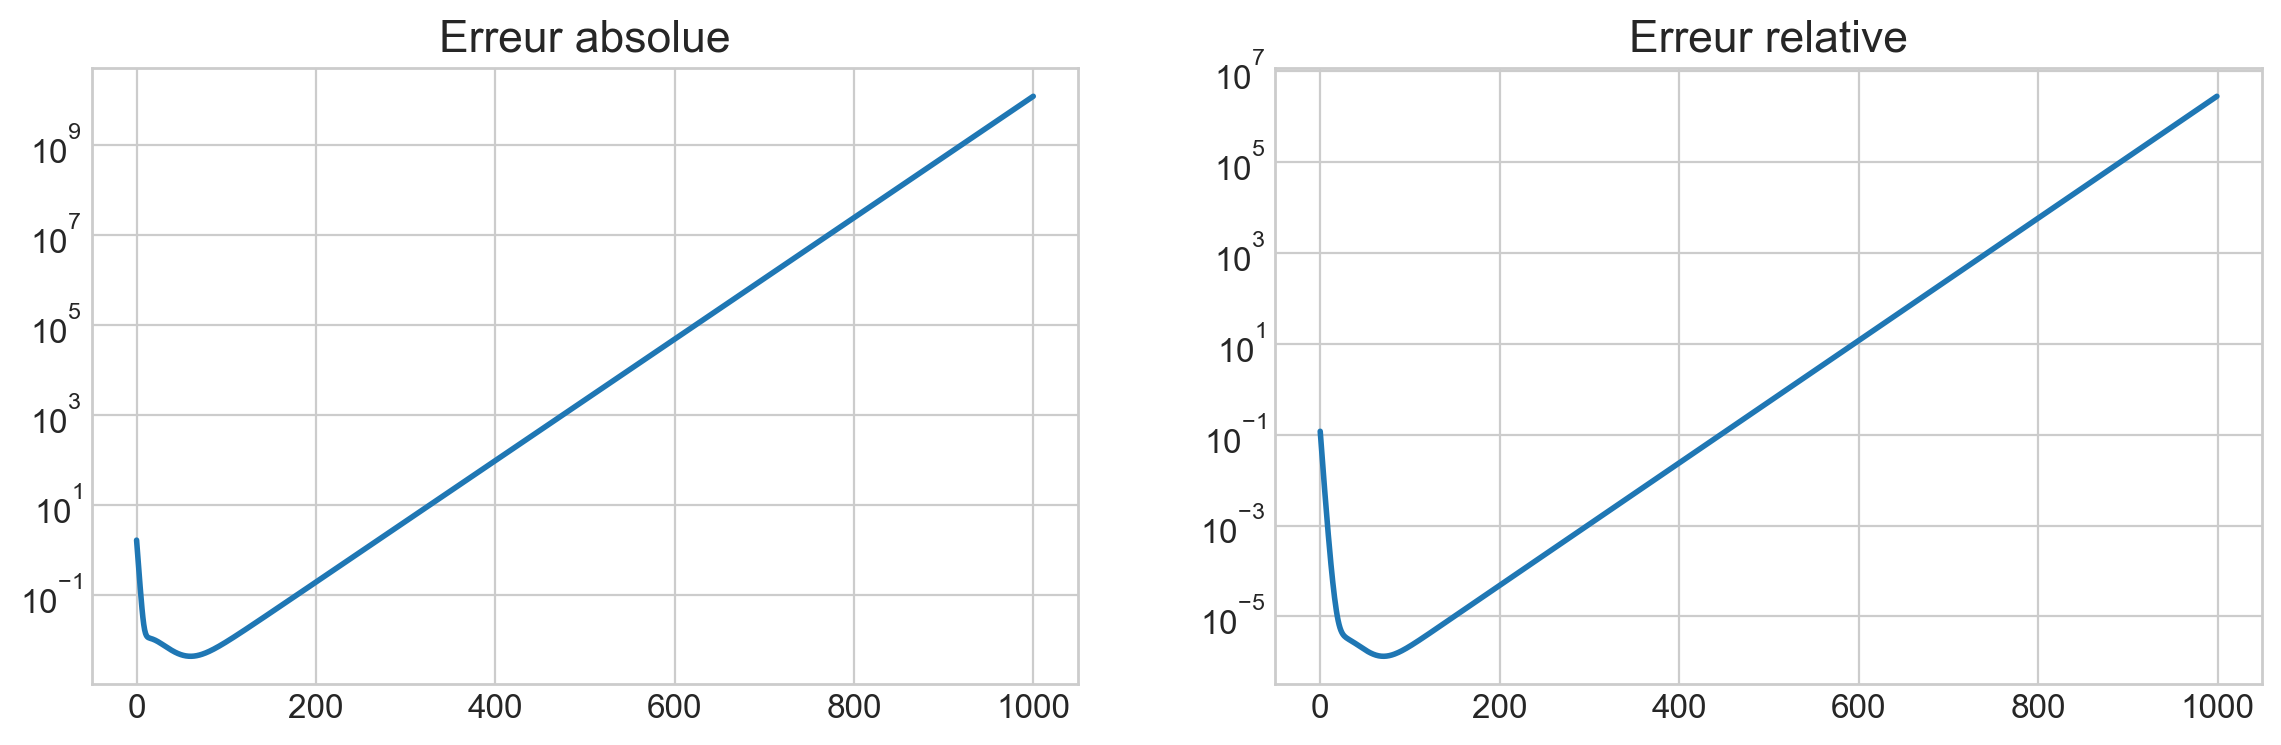

In [61]:
A = mk_A(799)
b = A.sum(axis=1)                    

M = np.diag(A)    
N = np.diag(M) - A 

x0 = np.random.random(4)
plot_error(M, N, b, x0, w=0.1, n=1000) 

Itération du minimum : 60 70


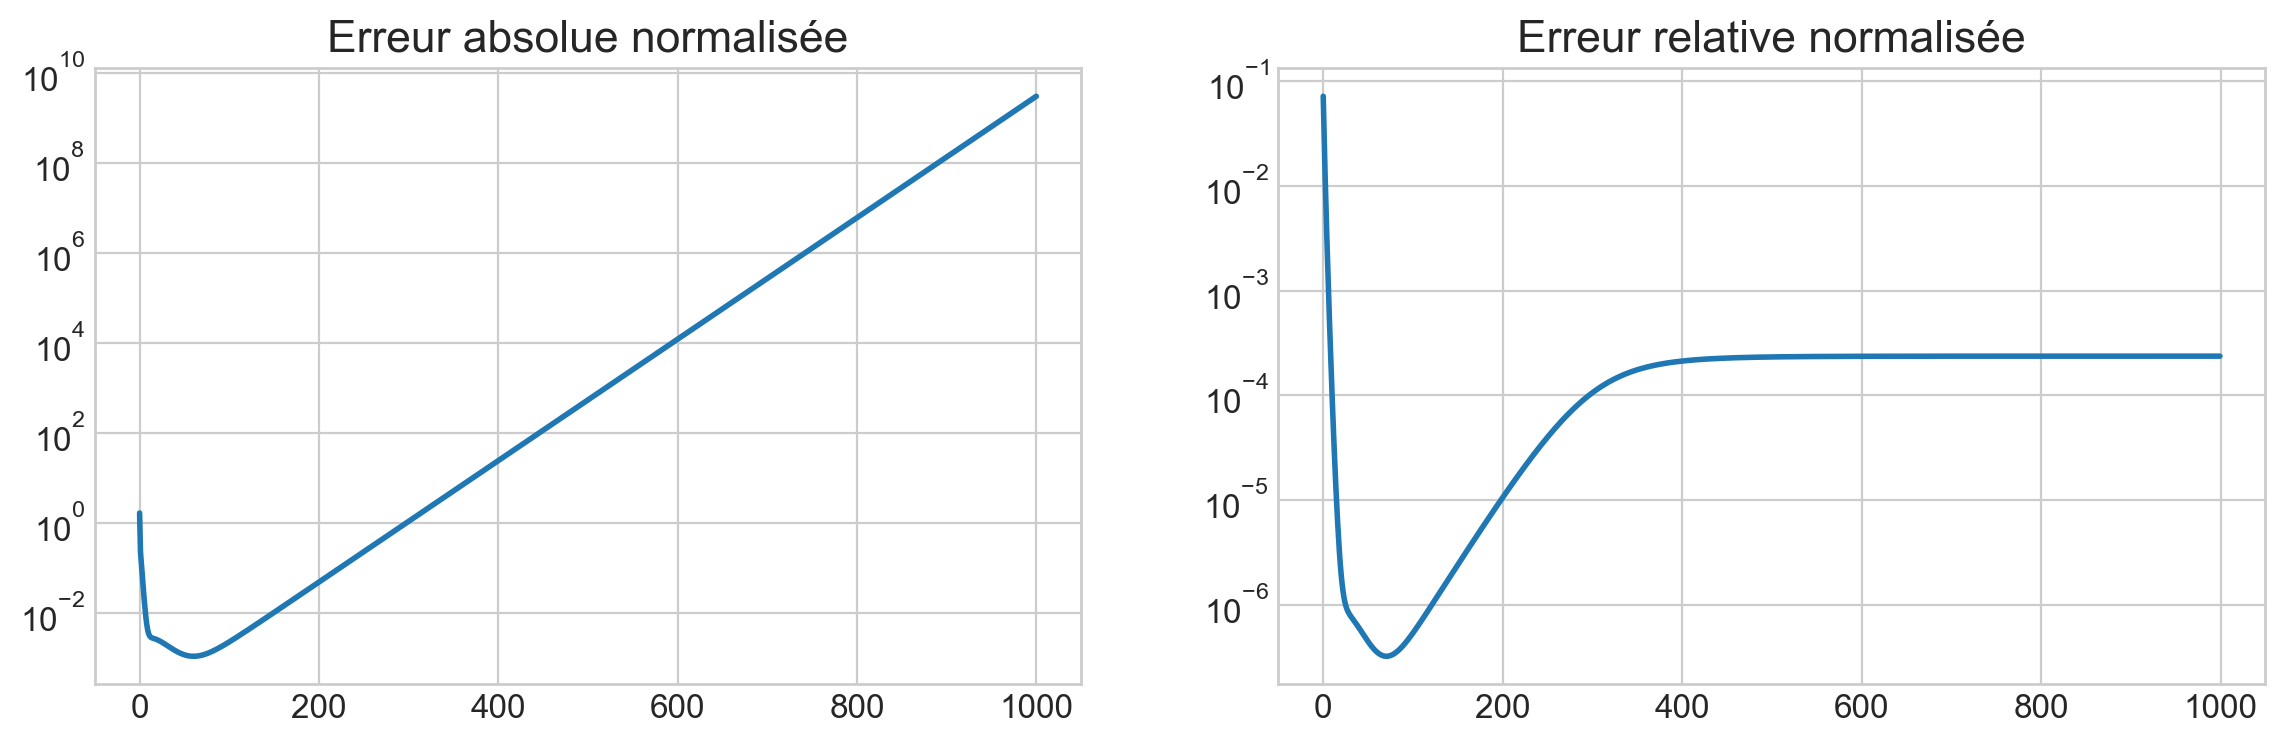

In [62]:
plot_error_normalized(M, N, b, x0, w=0.1, n=1000) 

Et oui, l'erreur relative normalisée se stabilise dans ce cas alors que non normalisée elle augmentait toujours.

Cela étant pour converger l'ecart entre 2 itérations doit tendre vers 0.

Parfois on peut avoir une surprise :

Itération du minimum : 500 499


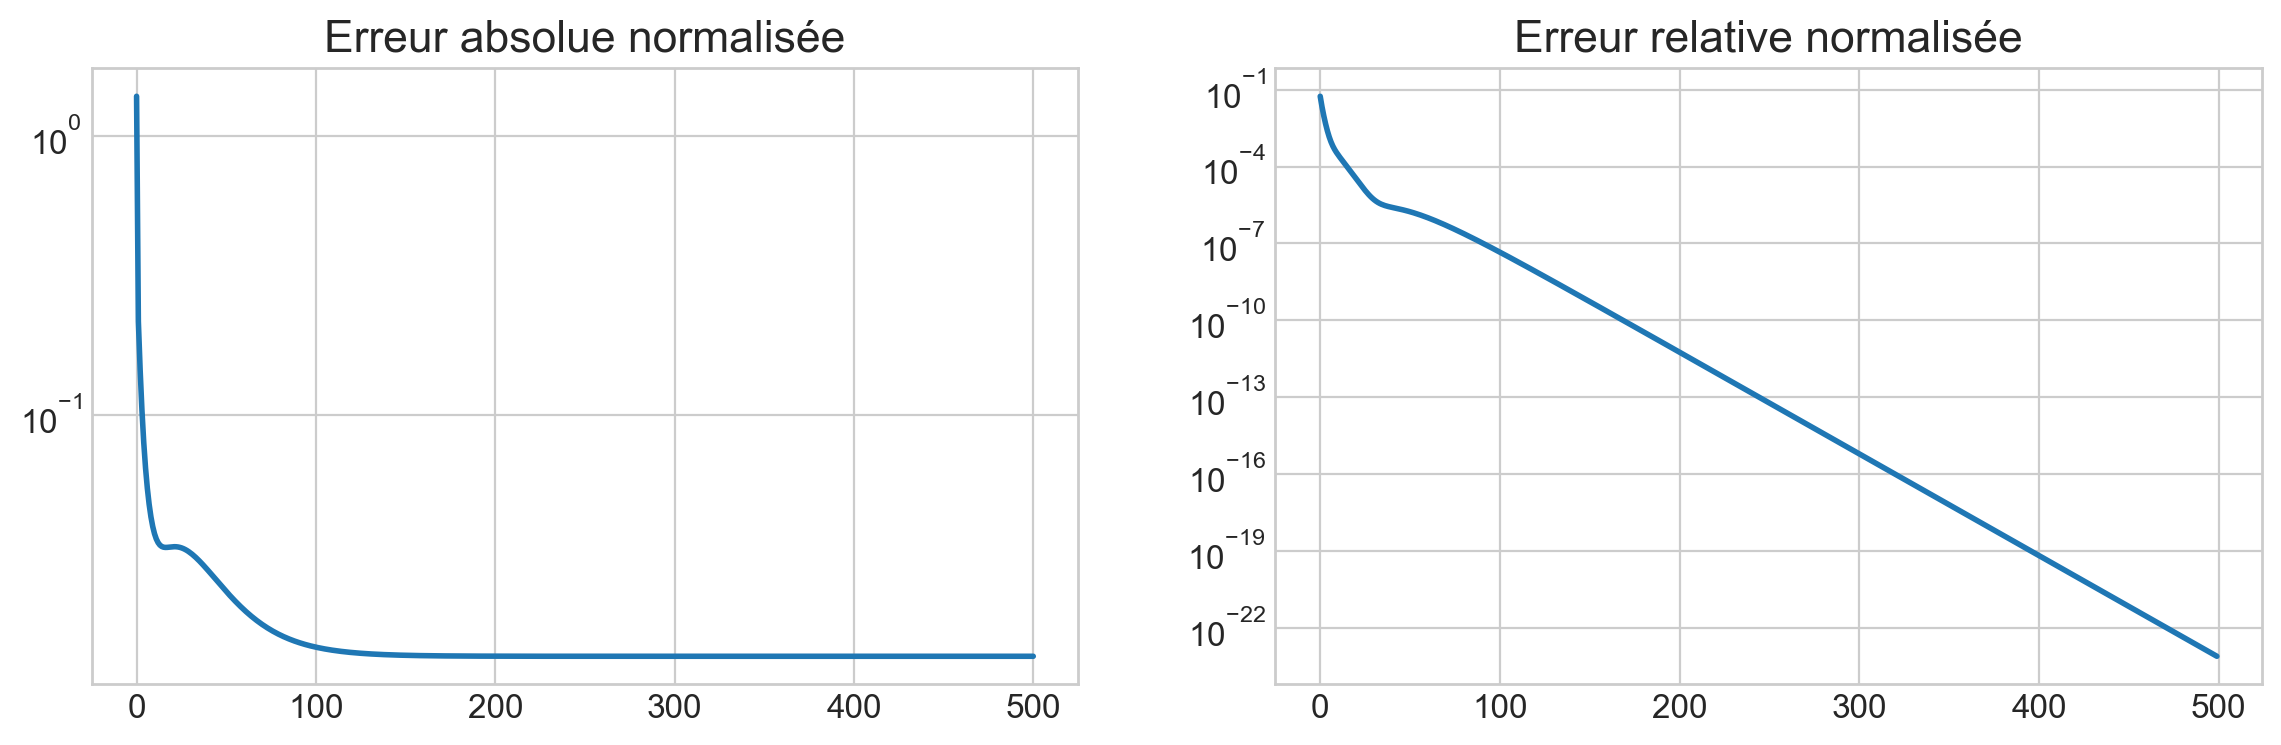

In [63]:
A = mk_A(308)
b = A.sum(axis=1)                    

M = np.diag(A)    
N = np.diag(M) - A 

x0 = np.random.random(4)
plot_error_normalized(M, N, b, x0, w=0.1, n=500) 

In [65]:
min(error)

0.0040626765429533146

On converge mais à coté de la valeur cherchée. C'est rare et c'est dû au très mauvais conditionnement
de la matrice A. Ce mauvais conditionnement génère des erreurs de calcul qui font qu'on ne peut pas arriver
à la solution exacte.


In [71]:
print(A)
print(np.linalg.cond(A))
# np.linalg.inv(A)
print(b)
print(A@np.array([1,1,1,1]))
np.linalg.solve(A,b)

[[7 2 8 8]
 [1 3 0 0]
 [0 4 5 5]
 [5 0 5 5]]
1.1405202107473442e+17
[25  4 14 15]
[25  4 14 15]


LinAlgError: Singular matrix